In [1]:
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'

In [2]:
# === Conexion Athena estilo Cruce + fallback awswrangler ===
import os
import re
import sys
from pathlib import Path

import boto3
import awswrangler as wr
import pandas as pd

EXPLICIT_CREDENTIALS_SH = Path(r"c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test/credentials.sh")


def _find_dir_with_athena_client(preferred_dir: Path | None = None) -> Path | None:
    cwd = Path.cwd().resolve()
    search_roots = []

    if preferred_dir is not None:
        search_roots.append(preferred_dir)

    search_roots.extend([cwd, *cwd.parents])

    home = Path.home()
    search_roots.extend([
        home / "OneDrive - Interbank" / "conexion_aws" / "athena_conection_test",
        Path("c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test"),
    ])

    visited = set()
    for root in search_roots:
        if root in visited:
            continue
        visited.add(root)

        if not root.exists():
            continue
        if (root / "athena_client.py").exists() and (root / "athena_config.json").exists():
            return root
    return None


def _load_credentials_from_sh(sh_path: Path) -> list[str]:
    if not sh_path.exists():
        return []

    loaded_keys: list[str] = []
    pattern = re.compile(r'^\s*export\s+([A-Za-z_][A-Za-z0-9_]*)=(.*)$')

    for line in sh_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = pattern.match(line)
        if not match:
            continue

        key, raw_val = match.groups()
        value = raw_val.strip().strip('"').strip("'")
        if key and value:
            os.environ[key] = value
            loaded_keys.append(key)

    return loaded_keys


def _build_session(aws_region: str) -> boto3.Session:
    aws_profile = os.getenv("AWS_PROFILE")
    if aws_profile:
        return boto3.Session(profile_name=aws_profile, region_name=aws_region)
    return boto3.Session(region_name=aws_region)


def _session_is_valid(sess: boto3.Session) -> tuple[bool, str | None]:
    try:
        sts = sess.client("sts")
        _ = sts.get_caller_identity()
        return True, None
    except Exception as exc:
        return False, str(exc)


ATHENA_MODE = "wrangler"
ATHENA_DATABASE = os.getenv("ATHENA_DATABASE", "disc_comercial")
ATHENA_WORKGROUP = os.getenv("ATHENA_WORKGROUP", "primary")
ATHENA_OUTPUT = os.getenv(
    "ATHENA_OUTPUT",
    "s3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/athena_results/"
 )
AWS_REGION = os.getenv("AWS_REGION", "us-east-1")

client = None

credentials_file = EXPLICIT_CREDENTIALS_SH if EXPLICIT_CREDENTIALS_SH.exists() else None
if credentials_file is None:
    print(f"⚠ No se encontró credentials.sh en ruta fija: {EXPLICIT_CREDENTIALS_SH}")

preferred_dir = credentials_file.parent if credentials_file is not None else None
athena_dir = _find_dir_with_athena_client(preferred_dir=preferred_dir)
loaded_cred_keys: list[str] = []

if credentials_file is not None:
    loaded_cred_keys = _load_credentials_from_sh(credentials_file)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {credentials_file}")
elif athena_dir is not None:
    fallback_sh = athena_dir / "credentials.sh"
    loaded_cred_keys = _load_credentials_from_sh(fallback_sh)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {fallback_sh}")

try:
    session = _build_session(AWS_REGION)
except Exception:
    session = boto3.Session(region_name=AWS_REGION)

ok_session, session_error = _session_is_valid(session)
if not ok_session and session_error and "ExpiredToken" in session_error and loaded_cred_keys:
    print("⚠ Se detectó token expirado en credentials.sh. Reintentando con credenciales locales (perfil/default)...")
    for key in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN"]:
        os.environ.pop(key, None)
    session = _build_session(AWS_REGION)

if athena_dir is not None:
    if str(athena_dir) not in sys.path:
        sys.path.append(str(athena_dir))
    try:
        from athena_client import AthenaClient

        if credentials_file is None:
            credentials_file = athena_dir / "credentials.sh"

        client = AthenaClient(
            credentials_file=str(credentials_file),
            config_file=str(athena_dir / "athena_config.json"),
        )
        ATHENA_MODE = "athena_client"
        print(f"✓ AthenaClient cargado desde: {athena_dir}")
    except Exception as exc:
        print(f"⚠ No se pudo inicializar AthenaClient ({exc}). Se usará awswrangler.")
else:
    print("⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.")


def athena_query(query: str, database: str = ATHENA_DATABASE) -> pd.DataFrame:
    if ATHENA_MODE == "athena_client" and client is not None:
        return client.query(query)
    return wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False,
        boto3_session=session,
        workgroup=ATHENA_WORKGROUP,
        s3_output=ATHENA_OUTPUT,
    )


def s3_read_csv(path: str, sep: str = "|", **kwargs) -> pd.DataFrame:
    return wr.s3.read_csv(path=path, sep=sep, boto3_session=session, **kwargs)


def test_aws_connection(sample_s3_path: str | None = None) -> None:
    sts = session.client("sts")
    ident = sts.get_caller_identity()
    print(f"✓ AWS Account: {ident.get('Account')} | ARN: {ident.get('Arn')}")

    if sample_s3_path:
        _ = wr.s3.read_csv(path=sample_s3_path, sep='|', boto3_session=session, nrows=1)
        print(f"✓ Lectura S3 OK: {sample_s3_path}")


print(f"Modo Athena activo: {ATHENA_MODE}")
print(f"DB: {ATHENA_DATABASE} | WG: {ATHENA_WORKGROUP}")
print(f"credentials.sh en uso: {credentials_file}")
print("Helper Athena: athena_query(query)")
print("Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')")
print("Diagnóstico opcional: test_aws_connection()")

✓ Credenciales cargadas desde: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.
Modo Athena activo: wrangler
DB: disc_comercial | WG: primary
credentials.sh en uso: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
Helper Athena: athena_query(query)
Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')
Diagnóstico opcional: test_aws_connection()


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
import pylab as pl

from collections import Counter
from sklearn.datasets import make_classification

In [4]:
# Función para comprimir datos #######################################################
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [5]:
import numpy as np

In [6]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

# MODELOS

In [ ]:
# from sagemaker.tuner import HyperparameterTuner  ← requiere sagemaker instalado
# El nombre del mejor job ya está hardcodeado en la celda de carga del modelo
nombre_exportado = 'hpo-plaft-pn-masivo-260623-2030-038-a07095fc'
print(nombre_exportado)


ModuleNotFoundError: No module named 'sagemaker'

In [7]:
!pip install xgboost --prefer-binary

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [8]:
import boto3
import tarfile
import xgboost as xgb
import os

# Parámetros
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'
nombre_exportado = 'hpo-plaft-pn-masivo-260624-1403-021-7fc44d9a'

# Descargar model.tar.gz desde S3
s3 = boto3.client('s3')

with open('model.tar.gz', 'wb') as f:
    s3.download_fileobj(
        bucket_name,
        f'{model_prefix}/MODEL/output/{nombre_exportado}/output/model.tar.gz',
        f
    )

# Extraer el archivo tar.gz
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    tar.extractall(path='model')

# Cargar el modelo con XGBoost
model_path = os.path.join('model', 'xgboost-model')
model = xgb.Booster()
model.load_model(model_path)

# ¡Listo! Ya podés usar model.predict(...) con DMatrix

C:\Users\b46637\AppData\Local\Temp\ipykernel_54592\784311577.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='model')


In [9]:
import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers_total.csv"
test_path         = f"{base_s3_path}/test_total.csv"
extras_test_path  = f"{base_s3_path}/extras_test_total.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar test SIN header, pero CON nombres correctos
# ===============================================================
df_test = pd.read_csv(test_path, header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original
df_test = pd.concat([df_test.reset_index(drop=True),
                     extras_test[['cod_mes', 'key_value', 'cuc_num']]], axis=1)

# ===============================================================
# 6. Filtrar solo los meses de interés
# ===============================================================
meses_filtro = [202508, 202510, 202511]
df_test = df_test[df_test['cod_mes'].isin(meses_filtro)].reset_index(drop=True)

print(f"\nFiltro aplicado: {meses_filtro}")
print(f"Meses presentes: {sorted(df_test['cod_mes'].unique())}")
print(f"Registros tras filtro: {df_test.shape[0]:,}")

# ===============================================================
# 7. Verificación final
# ===============================================================
print("\nListo! Todo cargado y filtrado correctamente desde S3")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

display(df_test[['key_value', 'cuc_num', 'cod_mes', 'target']].head())


Se cargaron 35 variables desde S3
Primeras 10 variables: ['target', 'concentracion_dia_max', 'n_canales_distintos', 'monto_max_soles', 'monto_debitos_soles', 'ratio_debito_credito', 'fe_ratio_salidas_entradas', 'n_trx_otros', 'monto_transferencias_soles', 'imp_trx_abonosefect_12m']

Shapes cargados desde S3:
  Test  : (13182690, 35)

Filtro aplicado: [202508, 202510, 202511]
Meses presentes: [np.float64(202508.0), np.float64(202510.0), np.float64(202511.0)]
Registros tras filtro: 4,831,860

Listo! Todo cargado y filtrado correctamente desde S3
df_test ahora tiene 38 columnas


,key_value,cuc_num,cod_mes,target
0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,202508.0,0.0
1,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,202508.0,0.0
2,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,202508.0,0.0
3,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,202508.0,0.0
4,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,202508.0,0.0


In [10]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [11]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 !='0')]

In [78]:
df_test_1=df_test

In [79]:
#meses_filtro = [202508, 202510, 202511]

#df_test_1 = df_test[df_test['cod_mes'].isin(meses_filtro)].copy()

#print(f"Meses seleccionados: {sorted(df_test_1['cod_mes'].unique())}")
#print(f"Registros filtrados: {df_test_1.shape[0]:,}")


In [80]:
# Guardar parquet en S3
#df_test_0426.to_parquet(
#    's3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/PLAFT/PJ/MINORISTA/DATA_INFERENCIA_PILOTO/202604.parquet',
#    index=False
#)

In [81]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_test_3 = df_test_1.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cuc_num' ,'cod_mes']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [82]:
df_test_3['prob'] = model.predict(dtest)

In [83]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_test_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508.0    0.402916
202510.0    0.436120
202511.0    0.452138
dtype: float64


C:\Users\b46637\AppData\Local\Temp\ipykernel_54592\29427415.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_test_3.groupby('cod_mes').apply(


In [17]:
gini_promedio = gini_por_mes.mean()

print(f"\nGini promedio de todos los meses: {gini_promedio:.4f}")



Gini promedio de todos los meses: 0.4304


In [18]:
#df_test_1 = df_test[df_test['cod_mes'].between(202508, 202604)].copy()

In [19]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
#df_test_2 = df_test_1.copy()
#df_test_3= df_test_2[(df_test_2.tipo_alerta_n2 =='AUTOMATICA')&(df_test_2.trx_riesgo_cliente !='A')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cuc_num' ,'cod_mes']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_1.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [22]:
predictions = model.predict(dtest)
y_test = df_test_1.target.to_frame()
y_test['prob'] = predictions
y_test_1=y_test['target'].values
y_score=y_test['prob'].values
y_test['Rangos']=pd.qcut(y_test['prob'],10,duplicates='drop')
Tabla_Deciles(y_test['target'],y_test['prob'],n=5)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.00015800000000000005, 0.0237]",966360,17,0.000018,0.200023,1.000000,966360,606
"(0.0237, 0.0583]",966334,56,0.000058,0.400040,0.971947,1932694,589
"(0.0583, 0.108]",966281,109,0.000113,0.600046,0.879538,2898975,533
"(0.108, 0.217]",966202,131,0.000136,0.800036,0.699670,3865177,424
"(0.217, 0.996]",966077,293,0.000303,1.000000,0.483498,4831254,293


In [24]:
# En lugar de construir X_shap con columnas aleatorias:
cols_excluir = {'key_value', 'cuc_num', 'cod_mes', 'target'}
_feat_cols = [c for c in df_test_1.columns if c not in cols_excluir]

# IMPORTANTE: Asegúrate de que _feat_cols esté en el mismo orden que headers
# Si tienes la lista original de headers del modelo, úsala:
_feat_cols = [c for c in column_order if c not in cols_excluir]  # column_order viene de headers_total.csv

In [25]:
print("Columnas en X_shap:", X_shap.shape[1])
print("Columnas esperadas por modelo:", model.num_features())

Columnas en X_shap: 34
Columnas esperadas por modelo: 47


In [37]:
%%time
query = """

WITH pd AS (
    SELECT DISTINCT
        -- Identificadores
        a.num_documento,
        a.codunico,
        date_format(
            date_parse(CAST(a.mes_base AS varchar), '%Y%m') + interval '1' month,
            '%Y%m'
        ) AS codmes_lag1,
        CAST(a.mes_base AS INTEGER) AS codmes

    

    FROM d_perm_aws.ds_alertplaft_mdl a
    WHERE a.mes_base between '202508' AND '202605'
      AND a.subsegmento  IN ('Masivo', 'Masivo Dependiente', 'Masivo Independiente')
),

target AS (
    SELECT 
        codunico,
        periodo_alerta,
        tipo_alerta_n2,
        trx_riesgo_cliente,
        MAX(calificacion_monitoreo) AS flg_alerta
    FROM e_perm_aws.t_alertas_plaft
    GROUP BY codunico, periodo_alerta, tipo_alerta_n2,trx_riesgo_cliente
)

SELECT 
    a.*,
    b.tipo_alerta_n2,
    b.trx_riesgo_cliente,
    CASE 
        WHEN b.flg_alerta = '1' THEN 1 
        ELSE 0 
    END AS target_m
FROM pd a
LEFT JOIN target b
    ON a.codunico = b.codunico
 AND cast(a.codmes as varchar) = b.periodo_alerta
where  b.tipo_alerta_n2 is not null

;"""
df_dataset = athena_query(query, database='disc_comercial')
df_dataset.head()

CPU times: total: 2.08 s
Wall time: 12.6 s


,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,01B3B2CE1C19A5CBDF2A2A379F98FF1D12C11FD3489828...,0021764087,202604,202603,SEMI AUTOMATICA,B,0
1,7F2F7B1AC71CBE9744F0ABB45E029CD96FF50BFDC21C0C...,0018793148,202603,202602,MANUAL,A,0
2,CDBF91AFC304EB8AFD2142EDA3C8003C86041490D663D6...,0009797833,202606,202605,MANUAL,B,1
3,D9B53EE7FE87EEA189549704BDBA7B49E84C5668FA0375...,0013229073,202601,202512,AUTOMATICA,A,0
4,D9B53EE7FE87EEA189549704BDBA7B49E84C5668FA0375...,0013229073,202601,202512,AUTOMATICA,M,0


In [38]:
len(df_dataset)


6940

In [39]:
df_test_3.head()

,target,concentracion_dia_max,n_canales_distintos,monto_max_soles,monto_debitos_soles,ratio_debito_credito,fe_ratio_salidas_entradas,n_trx_otros,monto_transferencias_soles,imp_trx_abonosefect_12m,...,monto_total_dolares,monto_promedio_dolares,mto_dif_abn_crgsefe_6m,n_trx_pagos,tc_total_monto_mes,flg_activo,cod_mes,key_value,cuc_num,prob
0,0.0,0.666667,3.0,200.00,199.60,2.000000,0.997950,0.0,201.60,0.0,...,0.0,0.0,-3094.6,0.0,0.00,0.0,202508.0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,0.006186
1,0.0,0.666667,3.0,1642.58,1642.63,2.000000,1.026637,2.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.00,1.0,202508.0,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,0.097668
2,0.0,0.134615,4.0,1369.62,4117.00,1.476190,0.838078,18.0,2829.00,0.0,...,0.0,0.0,-4810.0,4.0,0.00,1.0,202508.0,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,0.114175
3,0.0,0.108108,2.0,321.00,987.70,1.740741,1.034230,9.0,1379.70,720.0,...,0.0,0.0,-50.0,1.0,0.00,0.0,202508.0,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,0.047448
4,0.0,0.187500,4.0,12709.00,14168.20,1.000000,1.014612,7.0,25415.15,16490.0,...,0.0,0.0,-5870.0,6.0,26327.79,1.0,202508.0,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,0.103743


In [40]:
#df_final= df_test_3[['key_value', 'cuc_num', 'prob', 'codmes', 'num_documento', 'codunico']]

In [41]:
df_final= df_test_3[['key_value', 'cuc_num', 'prob', 'cod_mes']]

In [42]:
df_final.head()

,key_value,cuc_num,prob,cod_mes
0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,0.006186,202508.0
1,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,0.097668,202508.0
2,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,0.114175,202508.0
3,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,0.047448,202508.0
4,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,0.103743,202508.0


In [43]:
df_final= df_test_3

In [44]:
# Copias para no tocar los originales
df_final_m = df_final.copy()
df_dataset_m = df_dataset.copy()

# Normalizar claves
df_final_m["cuc_num"] = df_final_m["cuc_num"].astype(float).astype("Int64").astype(str)
df_final_m["cod_mes"] = df_final_m["cod_mes"].astype(float).astype("Int64").astype(str)

df_dataset_m["codunico"] = df_dataset_m["codunico"].astype("Int64").astype(str)
df_dataset_m["codmes"] = df_dataset_m["codmes"].astype("Int64").astype(str)

# Merge
df_merge = df_final_m.merge(
    df_dataset_m,
    how="inner",
    left_on=["cuc_num", "cod_mes"],
    right_on=["codunico", "codmes"]
)

print(df_merge.shape)
df_merge.head()

(1675, 46)


,target,concentracion_dia_max,n_canales_distintos,monto_max_soles,monto_debitos_soles,ratio_debito_credito,fe_ratio_salidas_entradas,n_trx_otros,monto_transferencias_soles,imp_trx_abonosefect_12m,...,key_value,cuc_num,prob,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,0.0,0.666667,6.0,53088.00,53106.00,6.500000,1.000037,6.0,53138.00,137407.00,...,66F048EAC9D09040B93AB99DAC48BAD366BE348E8AF231...,15562692,0.086310,66F048EAC9D09040B93AB99DAC48BAD366BE348E8AF231...,15562692,202509,202508,SEMI AUTOMATICA,A,1
1,0.0,0.113095,4.0,5070.00,27300.99,0.931034,1.093698,29.0,37506.07,88536.80,...,5027F4F72EA5B4C455F511F1DC2D0F5D45831B3A4F3E20...,15538083,0.800184,5027F4F72EA5B4C455F511F1DC2D0F5D45831B3A4F3E20...,15538083,202509,202508,AUTOMATICA,M,0
2,0.0,0.124224,6.0,33000.00,175888.86,1.175676,1.086557,41.0,137386.50,228788.25,...,5B7914E3FFD850A1BE039BC92D2B1D04977D7F851515D6...,13353580,0.943222,5B7914E3FFD850A1BE039BC92D2B1D04977D7F851515D6...,13353580,202509,202508,AUTOMATICA,A,1
3,0.0,0.250000,4.0,2040.00,5456.81,9.000000,241.238280,3.0,4663.80,186417.73,...,5704D4082297C940650EA616D6CAA9B76325606F43DE1D...,17531638,0.423348,5704D4082297C940650EA616D6CAA9B76325606F43DE1D...,17531638,202509,202508,MANUAL,B,1
4,0.0,0.160000,7.0,4465.45,24743.55,2.048780,1.063293,21.0,18545.80,4942.00,...,CB2B0A40C65E1E9718B214C16BA4BDE9AB950415F1C910...,9669926,0.947390,CB2B0A40C65E1E9718B214C16BA4BDE9AB950415F1C910...,9669926,202509,202508,AUTOMATICA,M,0


In [45]:
df_5 = df_merge[(df_merge.tipo_alerta_n2=='AUTOMATICA')]

In [46]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_5.groupby('cod_mes').apply(
    lambda x: gini(x['target_m'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508    0.074156
202510    0.136471
202511    0.263984
dtype: float64


C:\Users\b46637\AppData\Local\Temp\ipykernel_54592\2626577288.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_5.groupby('cod_mes').apply(


In [47]:
meses = [
    202508, 202510, 202511, 
    202601, 202602, 202603, 202604,202605
]

tablas_quintiles = {}

# Normalizo mes
#df_merge["codmes_final"] = df_merge["codmes_final"].astype(str)

for mes in meses:
    mes_str = str(mes)

    test_data = df_5[
        df_5["cod_mes"] == mes_str
    ].copy()

    if test_data.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    if "target_m" not in test_data.columns:
        raise ValueError("No existe la columna target en df_4")

    if "prob" not in test_data.columns:
        raise ValueError("No existe la columna prob en df_4")

    tablas_quintiles[mes_str] = Tabla_Deciles(
        test_data["target_m"],
        test_data["prob"],
        n=5
    )

    print(f"✅ Mes {mes_str}: {len(test_data):,} registros")

✅ Mes 202508: 215 registros
✅ Mes 202510: 334 registros
✅ Mes 202511: 251 registros
⚠️ Sin datos para mes 202601
⚠️ Sin datos para mes 202602
⚠️ Sin datos para mes 202603
⚠️ Sin datos para mes 202604
⚠️ Sin datos para mes 202605


In [48]:
tablas_quintiles['202508']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00669, 0.125]",38,5,0.116279,0.204301,1.000000,38,29
"(0.125, 0.298]",39,4,0.093023,0.413978,0.827586,77,24
"(0.298, 0.721]",37,6,0.139535,0.612903,0.689655,114,20
"(0.721, 0.918]",34,9,0.209302,0.795699,0.482759,148,14
"(0.918, 0.993]",38,5,0.116279,1.000000,0.172414,186,5


In [49]:
tablas_quintiles['202510']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00488, 0.138]",60,7,0.104478,0.200000,1.000000,60,34
"(0.138, 0.273]",65,2,0.029851,0.416667,0.794118,125,27
"(0.273, 0.573]",61,5,0.075758,0.620000,0.735294,186,25
"(0.573, 0.893]",56,11,0.164179,0.806667,0.588235,242,20
"(0.893, 0.994]",58,9,0.134328,1.000000,0.264706,300,9


In [50]:
tablas_quintiles['202601']

KeyError: '202601'

In [51]:
tablas_quintiles['202602']

KeyError: '202602'

In [52]:
tablas_quintiles['202603']

KeyError: '202603'

In [53]:
tablas_quintiles['202604']

KeyError: '202604'

In [54]:
tablas_quintiles['202605']

KeyError: '202605'

In [55]:
df_quintiles = pd.concat(
    [
        tabla.assign(mes=mes)
        for mes, tabla in tablas_quintiles.items()
    ],
    ignore_index=True
)

display(df_quintiles.head())

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1,mes
0,38,5,0.116279,0.204301,1.000000,38,29,202508
1,39,4,0.093023,0.413978,0.827586,77,24,202508
2,37,6,0.139535,0.612903,0.689655,114,20,202508
3,34,9,0.209302,0.795699,0.482759,148,14,202508
4,38,5,0.116279,1.000000,0.172414,186,5,202508


In [56]:
df_quintiles = pd.concat(
    [
        tabla.reset_index(drop=True).assign(
            mes=str(mes),
            Quintil=range(1, len(tabla) + 1)
        )
        for mes, tabla in tablas_quintiles.items()
    ],
    ignore_index=True
)

display(df_quintiles)

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1,mes,Quintil
0,38,5,0.116279,0.204301,1.000000,38,29,202508,1
1,39,4,0.093023,0.413978,0.827586,77,24,202508,2
2,37,6,0.139535,0.612903,0.689655,114,20,202508,3
3,34,9,0.209302,0.795699,0.482759,148,14,202508,4
4,38,5,0.116279,1.000000,0.172414,186,5,202508,5
5,60,7,0.104478,0.200000,1.000000,60,34,202510,1
6,65,2,0.029851,0.416667,0.794118,125,27,202510,2
7,61,5,0.075758,0.620000,0.735294,186,25,202510,3
8,56,11,0.164179,0.806667,0.588235,242,20,202510,4
9,58,9,0.134328,1.000000,0.264706,300,9,202510,5


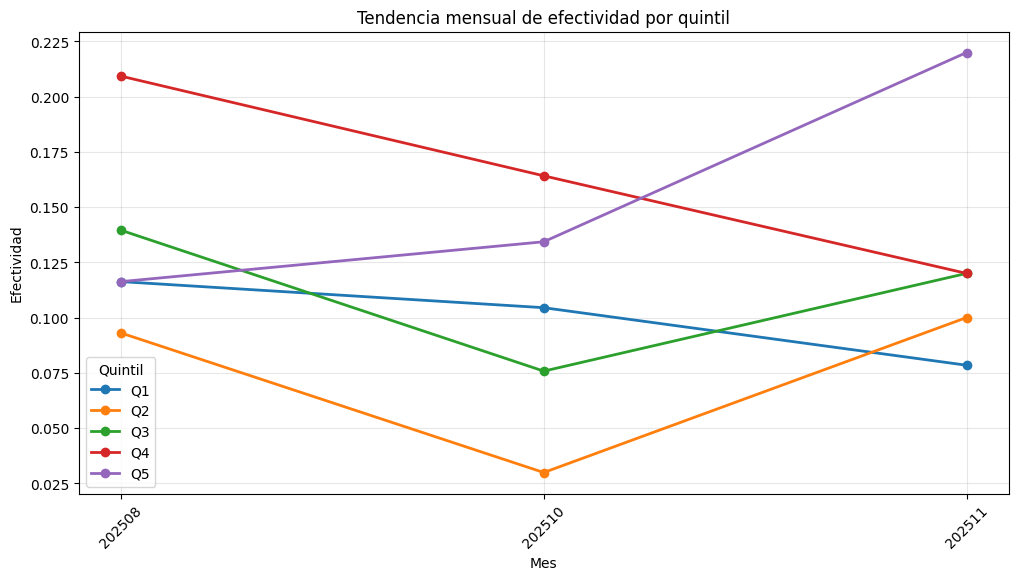

In [57]:
import matplotlib.pyplot as plt

pivot = df_quintiles.pivot_table(
    index="mes",
    columns="Quintil",
    values="Efectividad"
)

plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        linewidth=2,
        label=f"Q{col}"
    )

plt.title("Tendencia mensual de efectividad por quintil")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.legend(title="Quintil")
plt.xticks(rotation=45)
plt.show()

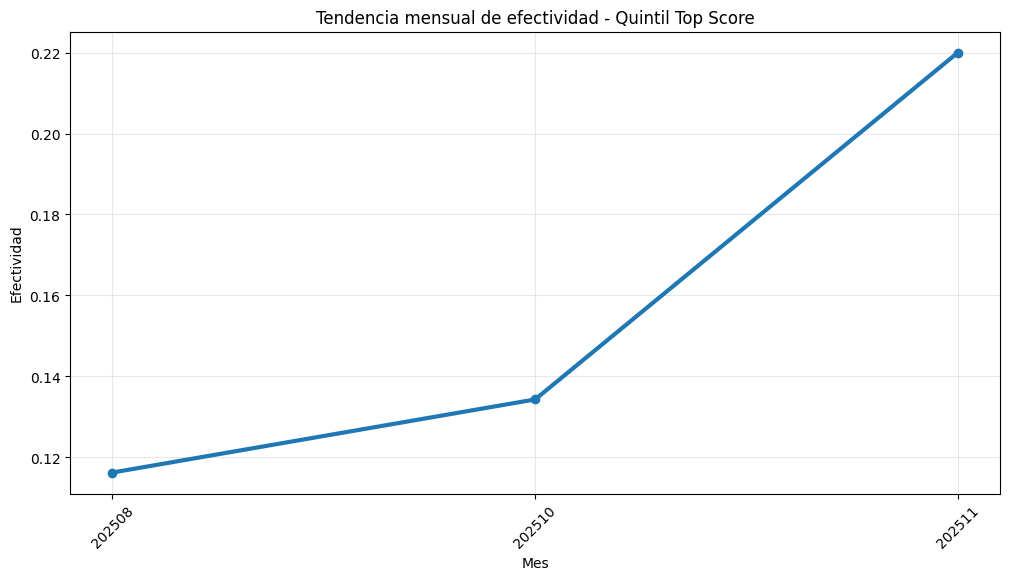

In [58]:
q_top = df_quintiles[df_quintiles["Quintil"] == 5].copy()

plt.figure(figsize=(12,6))

plt.plot(
    q_top["mes"],
    q_top["Efectividad"],
    marker="o",
    linewidth=3
)

plt.title("Tendencia mensual de efectividad - Quintil Top Score")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [59]:
# Meses a excluir
meses_excluir = ["202509", "202512","202601","202603"]

# Dataset para análisis
df_analisis = df_5[
    ~df_5["cod_mes"].astype(str).isin(meses_excluir)
].copy()

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1. Mes base para cortes
# ================================
mes_base = "202508"

df_analisis["cod_mes"] = df_analisis["cod_mes"].astype(str)
df_analisis["prob"] = pd.to_numeric(df_analisis["prob"], errors="coerce")
df_analisis["target_m"] = pd.to_numeric(df_analisis["target_m"], errors="coerce")

base = df_analisis[df_analisis["cod_mes"] == mes_base].copy()

# Cortes fijos según 202508
cuts = base["prob"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1]).values

# Evitar problemas si hay cortes repetidos
cuts[0] = -float("inf")
cuts[-1] = float("inf")

print("Cortes base 202508:")
print(cuts)

Cortes base 202508:
[      -inf 0.12494799 0.29790204 0.7207473  0.91819187        inf]


In [61]:


# ================================
# 2. Aplicar cortes fijos a todos los meses
# ================================
df_5["quintil_202508"] = pd.cut(
    df_5["prob"],
    bins=cuts,
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

# Q5 = mayor score
df_5["quintil_202508"] = df_5["quintil_202508"].astype(int)

C:\Users\b46637\AppData\Local\Temp\ipykernel_54592\3537661944.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_5["quintil_202508"] = pd.cut(
C:\Users\b46637\AppData\Local\Temp\ipykernel_54592\3537661944.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_5["quintil_202508"] = df_5["quintil_202508"].astype(int)


In [62]:
# ================================
# 3. Resumen por mes y quintil
# ================================
resumen_q = (
    df_analisis
    .groupby(["cod_mes", "quintil_202508"])
    .agg(
        cantidad=("target_m", "size"),
        casos_riesgo=("target_m", "sum"),
        efectividad=("target_m", "mean"),
        prob_min=("prob", "min"),
        prob_max=("prob", "max")
    )
    .reset_index()
)

display(resumen_q)

KeyError: 'quintil_202508'

In [63]:
# ================================
# 4. Gráfico tendencia mensual
# ================================
pivot = resumen_q.pivot_table(
    index="cod_mes",
    columns="quintil_202508",
    values="efectividad"
)

plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        linewidth=2,
        label=f"Q{col}"
    )

plt.title("Tendencia mensual de efectividad con cortes fijos de 202508")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.legend(title="Quintil")
plt.xticks(rotation=45)
plt.show()

NameError: name 'resumen_q' is not defined

In [64]:
q5 = resumen_q[resumen_q["quintil_202508"] == 5]

plt.figure(figsize=(12,6))

plt.plot(
    q5["cod_mes"],
    q5["efectividad"],
    marker="o",
    linewidth=3
)

plt.title("Tendencia mensual de efectividad - Q5 con cortes 202508")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

NameError: name 'resumen_q' is not defined

In [65]:
# Copias para no tocar los originales
df_final_m = df_final.copy()
df_dataset_m = df_dataset.copy()

# Normalizar claves
df_final_m["cuc_num"] = df_final_m["cuc_num"].astype(float).astype("Int64").astype(str)
df_final_m["cod_mes"] = df_final_m["cod_mes"].astype(float).astype("Int64").astype(str)

df_dataset_m["codunico"] = df_dataset_m["codunico"].astype("Int64").astype(str)
df_dataset_m["codmes"] = df_dataset_m["codmes"].astype("Int64").astype(str)

# Merge
df_merge = df_final_m.merge(
    df_dataset_m,
    how="left",
    left_on=["cuc_num", "cod_mes"],
    right_on=["codunico", "codmes"]
)

print(df_merge.shape)
df_merge.head()

(4831967, 46)


,target,concentracion_dia_max,n_canales_distintos,monto_max_soles,monto_debitos_soles,ratio_debito_credito,fe_ratio_salidas_entradas,n_trx_otros,monto_transferencias_soles,imp_trx_abonosefect_12m,...,key_value,cuc_num,prob,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,0.0,0.666667,3.0,200.00,199.60,2.000000,0.997950,0.0,201.60,0.0,...,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228,0.006186,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
1,0.0,0.666667,3.0,1642.58,1642.63,2.000000,1.026637,2.0,0.00,0.0,...,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426,0.097668,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
2,0.0,0.134615,4.0,1369.62,4117.00,1.476190,0.838078,18.0,2829.00,0.0,...,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602,0.114175,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
3,0.0,0.108108,2.0,321.00,987.70,1.740741,1.034230,9.0,1379.70,720.0,...,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200,0.047448,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
4,0.0,0.187500,4.0,12709.00,14168.20,1.000000,1.014612,7.0,25415.15,16490.0,...,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077,0.103743,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>


In [66]:
df_merge.cod_mes.value_counts()

cod_mes
202511    1623836
202510    1610062
202508    1598069
Name: count, dtype: int64

In [67]:
# ================================================================
# Eliminar casos duplicados en df_merge
# ================================================================
candidate_keys = [
    ["key_value", "cod_mes"],
    ["key_value", "cuc_num", "cod_mes"],
    ["cuc_num", "cod_mes"],
    ["codunico", "codmes"],
]

dedup_keys = next((k for k in candidate_keys if all(col in df_merge.columns for col in k)), None)
if dedup_keys is None:
    raise ValueError("No se encontró una combinación de llaves válida para deduplicar df_merge")

before_rows = len(df_merge)

# Priorizamos conservar el registro con mayor señal de riesgo
priority_cols = [c for c in ["target_m", "prob"] if c in df_merge.columns]
if priority_cols:
    df_merge = df_merge.sort_values(priority_cols, ascending=False)

duplicates_count = df_merge.duplicated(subset=dedup_keys, keep="first").sum()
df_merge = df_merge.drop_duplicates(subset=dedup_keys, keep="first").reset_index(drop=True)
after_rows = len(df_merge)

print(f"Llaves usadas para deduplicar: {dedup_keys}")
print(f"Filas antes: {before_rows:,}")
print(f"Duplicados eliminados: {duplicates_count:,}")
print(f"Filas después: {after_rows:,}")

# Verificación por mes
df_merge.cod_mes.value_counts()

Llaves usadas para deduplicar: ['key_value', 'cod_mes']
Filas antes: 4,831,967
Duplicados eliminados: 1,828
Filas después: 4,830,139


cod_mes
202511    1622970
202510    1609433
202508    1597736
Name: count, dtype: int64

In [68]:
import pandas as pd
import numpy as np

def metricas_top_k(df, target_col, score_col, k_list):
    """
    Calcula Recall@K y Precision@K para distintos valores de K
    """
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    total_positivos = df[target_col].sum()

    resultados = []

    for k in k_list:
        top_k = df.head(k)
        tp_k = top_k[target_col].sum()

        recall_k = tp_k / total_positivos if total_positivos > 0 else 0
        precision_k = tp_k / k if k > 0 else 0

        resultados.append({
            "K": k,
            "score_min": top_k[score_col].min(),
            "TP": tp_k,
            "Recall": recall_k,
            "Precision": precision_k
        })

    return pd.DataFrame(resultados)

In [69]:
meses = [202508, 202509, 202510, 202511, 202512, 202604, 202605]
k_list = [100, 200, 500, 1000, 2000]

resultados_meses = {}

for mes in meses:
    mes_str = str(mes)  # cod_mes en df_merge es string

    test_data_alerta = df_merge[df_merge["cod_mes"] == mes_str].copy()

    if test_data_alerta.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    # prob ya existe en df_merge, no hace falta re-predecir
    tabla_k = metricas_top_k(
        test_data_alerta,
        target_col="target_m",
        score_col="prob",
        k_list=k_list
    )

    tabla_k["mes"] = mes
    resultados_meses[mes] = tabla_k
    print(f"✅ Mes {mes_str}: {len(test_data_alerta):,} registros")


✅ Mes 202508: 1,597,736 registros
⚠️ Sin datos para mes 202509
✅ Mes 202510: 1,609,433 registros
✅ Mes 202510: 1,609,433 registros
✅ Mes 202511: 1,622,970 registros
⚠️ Sin datos para mes 202512
✅ Mes 202511: 1,622,970 registros
⚠️ Sin datos para mes 202512
⚠️ Sin datos para mes 202604
⚠️ Sin datos para mes 202605
⚠️ Sin datos para mes 202604
⚠️ Sin datos para mes 202605


In [70]:
df_metricas = pd.concat(
    resultados_meses.values(),
    ignore_index=True
)

df_metricas


,K,score_min,TP,Recall,Precision,mes
0,100,0.992120,0,0.000000,0.0000,202508
1,200,0.990956,1,0.008475,0.0050,202508
2,500,0.988546,2,0.016949,0.0040,202508
3,1000,0.985337,4,0.033898,0.0040,202508
4,2000,0.979317,7,0.059322,0.0035,202508
5,100,0.991888,0,0.000000,0.0000,202510
6,200,0.990559,0,0.000000,0.0000,202510
7,500,0.988219,0,0.000000,0.0000,202510
8,1000,0.984711,0,0.000000,0.0000,202510
9,2000,0.978926,1,0.009615,0.0005,202510


In [71]:
def optimal_threshold_topk(
    df,
    score_col="prob",
    target_col="target",
    k=1000,
    n_groups=5
):
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # Total positivos reales (para recall)
    total_positivos = (df[target_col] == 1).sum()

    # Nos quedamos solo con los top K
    df_topk = df.iloc[:k].copy()

    group_size = k // n_groups
    resultados = []

    acumulado = pd.DataFrame()

    for g in range(1, n_groups + 1):
        inicio = (g - 1) * group_size
        fin = g * group_size

        acumulado = df_topk.iloc[:fin]

        tp = (acumulado[target_col] == 1).sum()
        fp = fin - tp
        fn = total_positivos - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )

        threshold = acumulado[score_col].min()

        resultados.append({
            "grupo": g,
            "casos_hasta": fin,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(resultados)


In [72]:
resultados_mes = {}

for mes in meses:
    mes_str = str(mes)  # cod_mes en df_merge es string

    df_mes = df_merge[df_merge["cod_mes"] == mes_str].copy()

    if df_mes.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    # prob ya existe en df_merge, no hace falta re-predecir
    tabla = optimal_threshold_topk(
        df_mes,
        score_col="prob",
        target_col="target_m",  # columna correcta en df_merge
        k=1000,
        n_groups=5
    )

    resultados_mes[mes] = tabla
    print(f"✅ Mes {mes_str}: {len(df_mes):,} registros")


✅ Mes 202508: 1,597,736 registros
⚠️ Sin datos para mes 202509
⚠️ Sin datos para mes 202509
✅ Mes 202510: 1,609,433 registros
✅ Mes 202510: 1,609,433 registros
✅ Mes 202511: 1,622,970 registros
✅ Mes 202511: 1,622,970 registros
⚠️ Sin datos para mes 202512
⚠️ Sin datos para mes 202604
⚠️ Sin datos para mes 202605
⚠️ Sin datos para mes 202512
⚠️ Sin datos para mes 202604
⚠️ Sin datos para mes 202605


In [73]:
for mes, tabla in resultados_mes.items():
    print(f"\nMes {mes}")
    display(tabla.sort_values("f1", ascending=False).head(1))


Mes 202508


,grupo,casos_hasta,threshold,precision,recall,f1
3,4,800,0.986675,0.005,0.033898,0.008715



Mes 202510


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.990559,0.0,0.0,0



Mes 202511


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.990447,0.0,0.0,0


In [74]:
df_optimos = []

for mes, tabla in resultados_mes.items():
    best = tabla.sort_values("f1", ascending=False).iloc[0]
    best["mes"] = mes
    df_optimos.append(best)

df_optimos = pd.DataFrame(df_optimos)
df_optimos

,grupo,casos_hasta,threshold,precision,recall,f1,mes
3,4.0,800.0,0.986675,0.005,0.033898,0.008715,202508.0
0,1.0,200.0,0.990559,0.000,0.000000,0.000000,202510.0
0,1.0,200.0,0.990447,0.000,0.000000,0.000000,202511.0


In [75]:
# ================================================================
# Threshold final: percentil 75 de los thresholds óptimos por mes
# Cada mes aporta el score mínimo que maximizó F1 en ese mes.
# p75 → más restrictivo que el óptimo del 75% de los meses
#        → menos alertas, mayor precision
# ================================================================
threshold_final = df_optimos["threshold"].quantile(0.93)

print(f"Threshold final (p75): {threshold_final:.4f}\n")
print(f"Thresholds óptimos por mes (los que maximizan F1):")
display(df_optimos[["mes", "threshold", "precision", "recall", "f1"]])

print(f"\nImpacto del threshold {threshold_final:.4f} por mes:")
resumen_final = (
    df_merge[df_merge["prob"] >= threshold_final]
    .groupby("cod_mes")
    .agg(
        alertas=("prob", "count"),
        positivos=("target_m", "sum")
    )
    .assign(precision=lambda d: (d["positivos"] / d["alertas"]).round(3))
)
resumen_final.index = resumen_final.index.astype(str)
display(resumen_final)


Threshold final (p75): 0.9905

Thresholds óptimos por mes (los que maximizan F1):


,mes,threshold,precision,recall,f1
3,202508.0,0.986675,0.005,0.033898,0.008715
0,202510.0,0.990559,0.000,0.000000,0.000000
0,202511.0,0.990447,0.000,0.000000,0.000000



Impacto del threshold 0.9905 por mes:


,alertas,positivos,precision
cod_mes,,,
202508,236,1,0.004
202510,202,0,0.0
202511,187,0,0.0


In [ ]:
import pandas as pd
import numpy as np

# ================================================================
# Perfilamiento por grupos de score (P1 = mayor prob, P5 = menor prob)
# ================================================================

# Columnas que NO son variables del modelo
cols_no_vars = {'key_value', 'cuc_num', 'cod_mes', 'codunico', 'codmes',
                'num_documento', 'codmes_lag1', 'tipo_alerta_n2',
                'trx_riesgo_cliente', 'target_m', 'prob',
                'quintil_202508', 'flg_alerta'}

# 1. Ordenar por prob descendente y asignar grupos P1–P5
df_perfil = df_5.sort_values("prob", ascending=False).reset_index(drop=True)
df_perfil["grupo_score"] = pd.qcut(
    df_perfil.index,
    q=5,
    labels=["P1", "P2", "P3", "P4", "P5"]
)

print(f"Distribución de grupos:")
print(df_perfil["grupo_score"].value_counts().sort_index())
print(f"\nProb media por grupo:")
print(df_perfil.groupby("grupo_score")["prob"].mean().round(4))

# 2. Variables numéricas del modelo
vars_modelo = [c for c in df_5.columns
               if c not in cols_no_vars
               and pd.api.types.is_numeric_dtype(df_5[c])]

print(f"\nVariables analizadas: {len(vars_modelo)}")

# 3. Media por grupo para cada variable
perfil = (
    df_perfil.groupby("grupo_score")[vars_modelo]
    .mean()
    .T                              # variables como filas, grupos como columnas
    .round(4)
    .reset_index()
    .rename(columns={"index": "variable"})
)

# Añadir ratio P1/P5 para ver qué variables distinguen más
perfil["ratio_P1_P5"] = (perfil["P1"] / perfil["P5"].replace(0, np.nan)).round(2)
perfil = perfil.sort_values("ratio_P1_P5", ascending=False).reset_index(drop=True)

print("\n--- Perfil de variables por grupo de score (top 30 por ratio P1/P5) ---")
display(
    perfil.head(30)
    .style
    .format({col: "{:.4f}" for col in ["P1","P2","P3","P4","P5","ratio_P1_P5"]})
    .background_gradient(subset=["P1","P2","P3","P4","P5"], cmap="RdYlGn_r", axis=1)
)


Distribución de grupos:
grupo_score
P1    160
P2    160
P3    160
P4    160
P5    160
Name: count, dtype: int64

Prob media por grupo:
grupo_score
P1    0.9445
P2    0.7583
P3    0.4364
P4    0.1877
P5    0.0621
Name: prob, dtype: float32

Variables analizadas: 35

--- Perfil de variables por grupo de score (top 30 por ratio P1/P5) ---


C:\Users\b46637\AppData\Local\Temp\ipykernel_54592\2656403351.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_perfil.groupby("grupo_score")["prob"].mean().round(4))
C:\Users\b46637\AppData\Local\Temp\ipykernel_54592\2656403351.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_perfil.groupby("grupo_score")[vars_modelo]


grupo_score,variable,P1,P2,P3,P4,P5,ratio_P1_P5
0,monto_total_dolares,179733.2982,95603.0358,65132.2929,40973.7336,132.4856,1356.6300
1,monto_promedio_dolares,9324.6907,10689.1570,6317.2272,13183.3057,69.3326,134.4900
2,tc_total_monto_mes,10670.3477,8097.7743,2234.4506,1878.4840,370.3457,28.8100
3,cnt_trx_abonosefect_12m,86.8188,65.4312,116.9125,32.8250,5.0250,17.2800
4,imp_trx_abonosefect_12m,780267.2409,281027.4052,717576.2207,307819.7906,93124.3205,8.3800
5,n_trx_pagos,3.2625,2.3438,1.5625,0.7875,0.4562,7.1500
6,monto_efectivo_soles,93345.5186,55254.4453,77506.4709,63719.0831,21081.2259,4.4300
7,imp_trx_cargosefe_12m,1060438.7525,515376.1430,436763.9014,692265.8493,262570.4237,4.0400
8,td_monto_total,3537.8208,2790.8700,8145.5588,701.6861,909.8827,3.8900
9,flg_activo,0.7250,0.5812,0.4938,0.4125,0.2125,3.4100


In [77]:
# ================================================================
# Tabla completa (todas las variables) – exportar a CSV
# ================================================================
perfil_completo = (
    df_perfil.groupby("grupo_score")[vars_modelo]
    .mean()
    .T
    .round(4)
    .reset_index()
    .rename(columns={"index": "variable"})
)
perfil_completo["ratio_P1_P5"] = (
    perfil_completo["P1"] / perfil_completo["P5"].replace(0, np.nan)
).round(2)
perfil_completo = perfil_completo.sort_values("ratio_P1_P5", ascending=False).reset_index(drop=True)

perfil_completo.to_csv("perfil_grupos_score.csv", index=False)
print(f"✅ Exportado: perfil_grupos_score.csv  ({len(perfil_completo)} variables)")
display(perfil_completo)


✅ Exportado: perfil_grupos_score.csv  (35 variables)


C:\Users\b46637\AppData\Local\Temp\ipykernel_54592\372227392.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_perfil.groupby("grupo_score")[vars_modelo]


grupo_score,variable,P1,P2,P3,P4,P5,ratio_P1_P5
0,monto_total_dolares,1.797333e+05,95603.0358,65132.2929,40973.7336,132.4856,1356.63
1,monto_promedio_dolares,9.324691e+03,10689.1570,6317.2272,13183.3057,69.3326,134.49
2,tc_total_monto_mes,1.067035e+04,8097.7743,2234.4506,1878.4840,370.3457,28.81
3,cnt_trx_abonosefect_12m,8.681880e+01,65.4312,116.9125,32.8250,5.0250,17.28
4,imp_trx_abonosefect_12m,7.802672e+05,281027.4052,717576.2207,307819.7906,93124.3205,8.38
5,n_trx_pagos,3.262500e+00,2.3438,1.5625,0.7875,0.4562,7.15
6,monto_efectivo_soles,9.334552e+04,55254.4453,77506.4709,63719.0831,21081.2259,4.43
7,imp_trx_cargosefe_12m,1.060439e+06,515376.1430,436763.9014,692265.8493,262570.4237,4.04
8,td_monto_total,3.537821e+03,2790.8700,8145.5588,701.6861,909.8827,3.89
9,flg_activo,7.250000e-01,0.5812,0.4938,0.4125,0.2125,3.41
